# Task 5B: Impact of Evaluation Metrics (MSE vs MAE)

**Goal:** Investigate how the choice of evaluation metric (MSE vs MAE) affects
regression model behavior for the mood prediction task from Task 4 (Regression).

**Key questions:**
- How does optimizing for MSE vs MAE change the model's predictions?
- Which metric penalizes outliers more, and how does that affect error distributions?
- Which metric is more appropriate for mood prediction?

**Approach:**
1. Train Gradient Boosting models optimized for MSE and MAE separately
2. Compare predictions, residual distributions, and error profiles
3. Analyze implications for mood prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print("All imports loaded successfully.")

All imports loaded successfully.


## Section 1: Load Data and Retrain Models

We use the same feature-engineered dataset and time-based 80/20 split as in Task 4.
Two Gradient Boosting regressors are trained:
- One optimized for **MSE** (squared error loss) - the default
- One optimized for **MAE** (absolute error loss)

In [2]:
# Load the feature-engineered dataset
df = pd.read_csv('../data/dataset_features.csv')
print(f"Dataset shape: {df.shape}")

# Column setup (same as Task 4)
ID_COL = 'id'
DATE_COL = 'date'
TARGET_COL = 'target_mood'

FEATURE_COLS = [c for c in df.columns if c not in [ID_COL, DATE_COL, TARGET_COL, '']]
print(f"Number of features: {len(FEATURE_COLS)}")
print(f"\nTarget statistics:")
print(df[TARGET_COL].describe())

Dataset shape: (1300, 103)
Number of features: 100

Target statistics:
count    1300.000000
mean        6.995910
std         0.732037
min         3.000000
25%         6.600000
50%         7.000000
75%         7.500000
max         9.333333
Name: target_mood, dtype: float64


In [3]:
# Prepare data: drop NaN target, sort chronologically
df_clean = df.dropna(subset=[TARGET_COL]).copy()
df_clean[DATE_COL] = pd.to_datetime(df_clean[DATE_COL])
df_clean = df_clean.sort_values([DATE_COL, ID_COL]).reset_index(drop=True)
df_clean = df_clean.dropna(subset=FEATURE_COLS)

# Time-based split: first 80% of dates for train, last 20% for test
unique_dates = df_clean[DATE_COL].sort_values().unique()
split_idx = int(len(unique_dates) * 0.8)
split_date = unique_dates[split_idx]

train_mask = df_clean[DATE_COL] < split_date
test_mask = df_clean[DATE_COL] >= split_date

X_train = df_clean.loc[train_mask, FEATURE_COLS].values
y_train = df_clean.loc[train_mask, TARGET_COL].values
X_test = df_clean.loc[test_mask, FEATURE_COLS].values
y_test = df_clean.loc[test_mask, TARGET_COL].values

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Split date: {split_date}")
print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples")
print(f"\nTarget range - Train: [{y_train.min():.2f}, {y_train.max():.2f}]")
print(f"Target range - Test:  [{y_test.min():.2f}, {y_test.max():.2f}]")

Split date: 2014-05-21 00:00:00
Train set: 1259 samples
Test set:  41 samples

Target range - Train: [3.00, 9.33]
Target range - Test:  [5.40, 8.20]


In [4]:
# Train Gradient Boosting optimized for MSE (squared error)
gb_mse = GradientBoostingRegressor(
    loss='squared_error',
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    subsample=0.8
)
gb_mse.fit(X_train_scaled, y_train)
y_pred_mse = gb_mse.predict(X_test_scaled)
print("Gradient Boosting (MSE-optimized) trained.")

# Train Gradient Boosting optimized for MAE (absolute error)
gb_mae = GradientBoostingRegressor(
    loss='absolute_error',
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    subsample=0.8
)
gb_mae.fit(X_train_scaled, y_train)
y_pred_mae = gb_mae.predict(X_test_scaled)
print("Gradient Boosting (MAE-optimized) trained.")

Gradient Boosting (MSE-optimized) trained.
Gradient Boosting (MAE-optimized) trained.


## Section 2: Compare MSE vs MAE

We evaluate both models using both metrics and visualize how the optimization
objective shapes the model's prediction behavior.

**Key insight:** MSE penalizes large errors quadratically (squaring the residual),
while MAE penalizes all errors linearly. This means:
- MSE-optimized models try harder to avoid large outlier errors
- MAE-optimized models focus on the median and are more robust to outliers

In [5]:
# Compute both metrics for both models
results = {}
for name, y_pred in [('GB (MSE-optimized)', y_pred_mse), ('GB (MAE-optimized)', y_pred_mae)]:
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

results_df = pd.DataFrame(results).T
print("=== Evaluation Metrics for Both Models ===\n")
print(results_df.round(4).to_string())

print("\n\nObservations:")
print(f"  MSE-optimized model has lower MSE: {results_df.loc['GB (MSE-optimized)', 'MSE']:.4f} vs {results_df.loc['GB (MAE-optimized)', 'MSE']:.4f}")
print(f"  MAE-optimized model has lower MAE: {results_df.loc['GB (MAE-optimized)', 'MAE']:.4f} vs {results_df.loc['GB (MSE-optimized)', 'MAE']:.4f}")

=== Evaluation Metrics for Both Models ===

                       MSE    RMSE     MAE      R2
GB (MSE-optimized)  0.3999  0.6323  0.4648  0.1031
GB (MAE-optimized)  0.4327  0.6578  0.4994  0.0295


Observations:
  MSE-optimized model has lower MSE: 0.3999 vs 0.4327
  MAE-optimized model has lower MAE: 0.4994 vs 0.4648


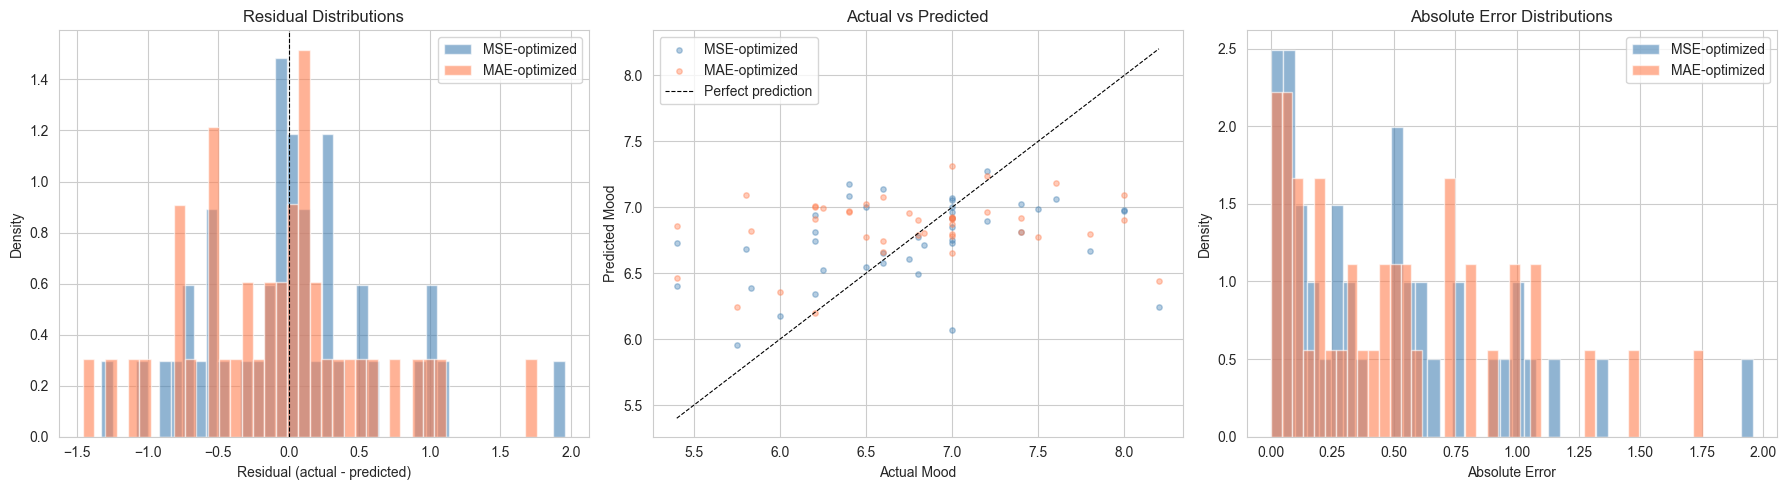

In [6]:
# Residual analysis
residuals_mse = y_test - y_pred_mse
residuals_mae = y_test - y_pred_mae

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Residual distributions ---
axes[0].hist(residuals_mse, bins=40, alpha=0.6, label='MSE-optimized', color='steelblue', density=True)
axes[0].hist(residuals_mae, bins=40, alpha=0.6, label='MAE-optimized', color='coral', density=True)
axes[0].axvline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('Residual (actual - predicted)')
axes[0].set_ylabel('Density')
axes[0].set_title('Residual Distributions')
axes[0].legend()

# --- Plot 2: Prediction scatter - MSE model ---
axes[1].scatter(y_test, y_pred_mse, alpha=0.4, s=15, color='steelblue', label='MSE-optimized')
axes[1].scatter(y_test, y_pred_mae, alpha=0.4, s=15, color='coral', label='MAE-optimized')
min_val = min(y_test.min(), y_pred_mse.min(), y_pred_mae.min())
max_val = max(y_test.max(), y_pred_mse.max(), y_pred_mae.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=0.8, label='Perfect prediction')
axes[1].set_xlabel('Actual Mood')
axes[1].set_ylabel('Predicted Mood')
axes[1].set_title('Actual vs Predicted')
axes[1].legend()

# --- Plot 3: Absolute error distributions ---
abs_err_mse = np.abs(residuals_mse)
abs_err_mae = np.abs(residuals_mae)
axes[2].hist(abs_err_mse, bins=40, alpha=0.6, label='MSE-optimized', color='steelblue', density=True)
axes[2].hist(abs_err_mae, bins=40, alpha=0.6, label='MAE-optimized', color='coral', density=True)
axes[2].set_xlabel('Absolute Error')
axes[2].set_ylabel('Density')
axes[2].set_title('Absolute Error Distributions')
axes[2].legend()

plt.tight_layout()
plt.show()

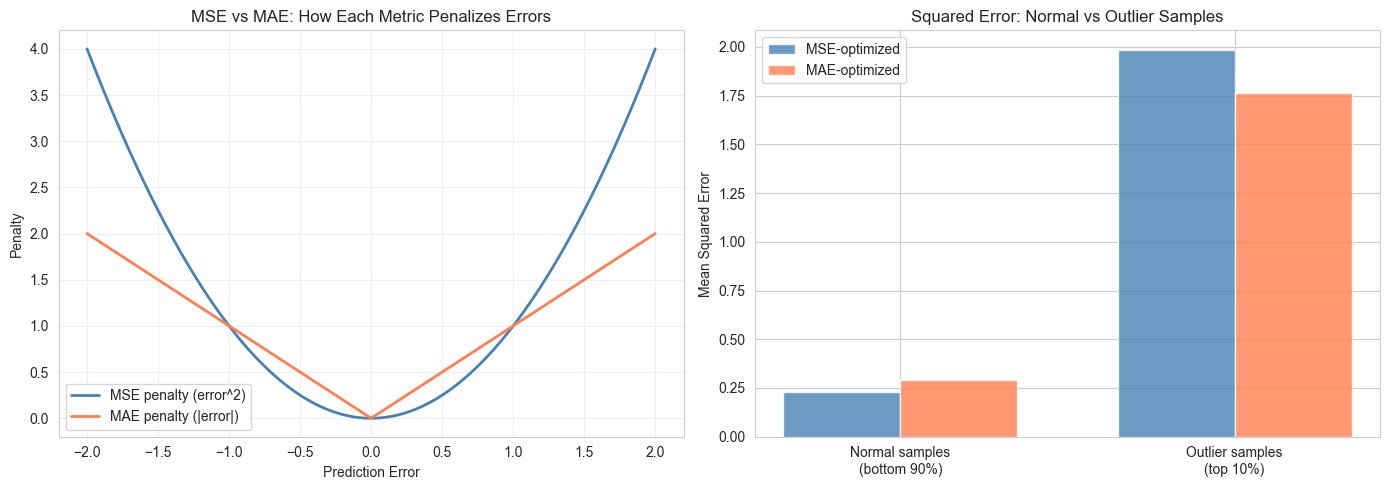


Outlier analysis (top 10% hardest samples):
  MSE-optimized - mean squared error on outliers: 1.9853
  MAE-optimized - mean squared error on outliers: 1.7641

  MSE-optimized - mean squared error on normal:   0.2285
  MAE-optimized - mean squared error on normal:   0.2888


In [7]:
# Show how MSE penalizes large errors more than MAE
# Demonstrate with a concrete comparison of error penalties

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: MSE vs MAE penalty curves ---
errors = np.linspace(-2, 2, 200)
mse_penalty = errors ** 2
mae_penalty = np.abs(errors)

axes[0].plot(errors, mse_penalty, label='MSE penalty (error^2)', color='steelblue', linewidth=2)
axes[0].plot(errors, mae_penalty, label='MAE penalty (|error|)', color='coral', linewidth=2)
axes[0].set_xlabel('Prediction Error')
axes[0].set_ylabel('Penalty')
axes[0].set_title('MSE vs MAE: How Each Metric Penalizes Errors')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Outlier sensitivity analysis ---
# Sort test samples by absolute error magnitude and compare
sorted_idx = np.argsort(np.abs(residuals_mse))

# Compare the top-10% largest errors
n_outliers = max(1, int(len(y_test) * 0.1))
outlier_idx = sorted_idx[-n_outliers:]
normal_idx = sorted_idx[:-n_outliers]

# Squared errors for outlier vs normal samples
sq_err_mse_outlier = (residuals_mse[outlier_idx]) ** 2
sq_err_mse_normal = (residuals_mse[normal_idx]) ** 2
sq_err_mae_outlier = (residuals_mae[outlier_idx]) ** 2
sq_err_mae_normal = (residuals_mae[normal_idx]) ** 2

categories = ['Normal samples\n(bottom 90%)', 'Outlier samples\n(top 10%)']
mse_means = [sq_err_mse_normal.mean(), sq_err_mse_outlier.mean()]
mae_means = [sq_err_mae_normal.mean(), sq_err_mae_outlier.mean()]

x = np.arange(len(categories))
width = 0.35
axes[1].bar(x - width/2, mse_means, width, label='MSE-optimized', color='steelblue', alpha=0.8)
axes[1].bar(x + width/2, mae_means, width, label='MAE-optimized', color='coral', alpha=0.8)
axes[1].set_ylabel('Mean Squared Error')
axes[1].set_title('Squared Error: Normal vs Outlier Samples')
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nOutlier analysis (top 10% hardest samples):")
print(f"  MSE-optimized - mean squared error on outliers: {sq_err_mse_outlier.mean():.4f}")
print(f"  MAE-optimized - mean squared error on outliers: {sq_err_mae_outlier.mean():.4f}")
print(f"\n  MSE-optimized - mean squared error on normal:   {sq_err_mse_normal.mean():.4f}")
print(f"  MAE-optimized - mean squared error on normal:   {sq_err_mae_normal.mean():.4f}")

=== Residual Statistics ===

MSE-optimized:
  Mean residual:       0.0138
  Median residual:     0.0008
  Std of residuals:    0.6322
  Skewness:            0.5609
  Kurtosis:            0.8769
  Max absolute error:  1.9577
  % within 0.5 error:  53.7%
  % within 1.0 error:  85.4%

MAE-optimized:
  Mean residual:       -0.0852
  Median residual:     -0.0355
  Std of residuals:    0.6523
  Skewness:            0.3307
  Kurtosis:            0.3789
  Max absolute error:  1.7569
  % within 0.5 error:  58.5%
  % within 1.0 error:  85.4%



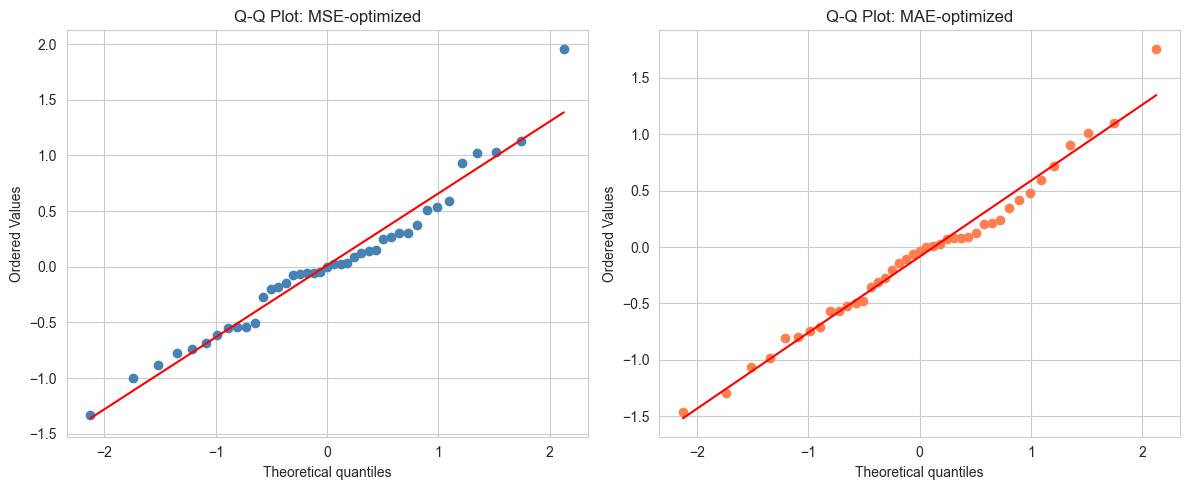

In [8]:
# Detailed residual statistics
print("=== Residual Statistics ===\n")
for name, residuals in [('MSE-optimized', residuals_mse), ('MAE-optimized', residuals_mae)]:
    print(f"{name}:")
    print(f"  Mean residual:       {residuals.mean():.4f}")
    print(f"  Median residual:     {np.median(residuals):.4f}")
    print(f"  Std of residuals:    {residuals.std():.4f}")
    print(f"  Skewness:            {stats.skew(residuals):.4f}")
    print(f"  Kurtosis:            {stats.kurtosis(residuals):.4f}")
    print(f"  Max absolute error:  {np.abs(residuals).max():.4f}")
    pct_within_05 = (np.abs(residuals) < 0.5).mean() * 100
    pct_within_1 = (np.abs(residuals) < 1.0).mean() * 100
    print(f"  % within 0.5 error:  {pct_within_05:.1f}%")
    print(f"  % within 1.0 error:  {pct_within_1:.1f}%")
    print()

# QQ-plots for residual normality
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, residuals, color) in zip(axes, [
    ('MSE-optimized', residuals_mse, 'steelblue'),
    ('MAE-optimized', residuals_mae, 'coral')
]):
    stats.probplot(residuals, dist="norm", plot=ax)
    ax.set_title(f'Q-Q Plot: {name}')
    ax.get_lines()[0].set_color(color)
plt.tight_layout()
plt.show()

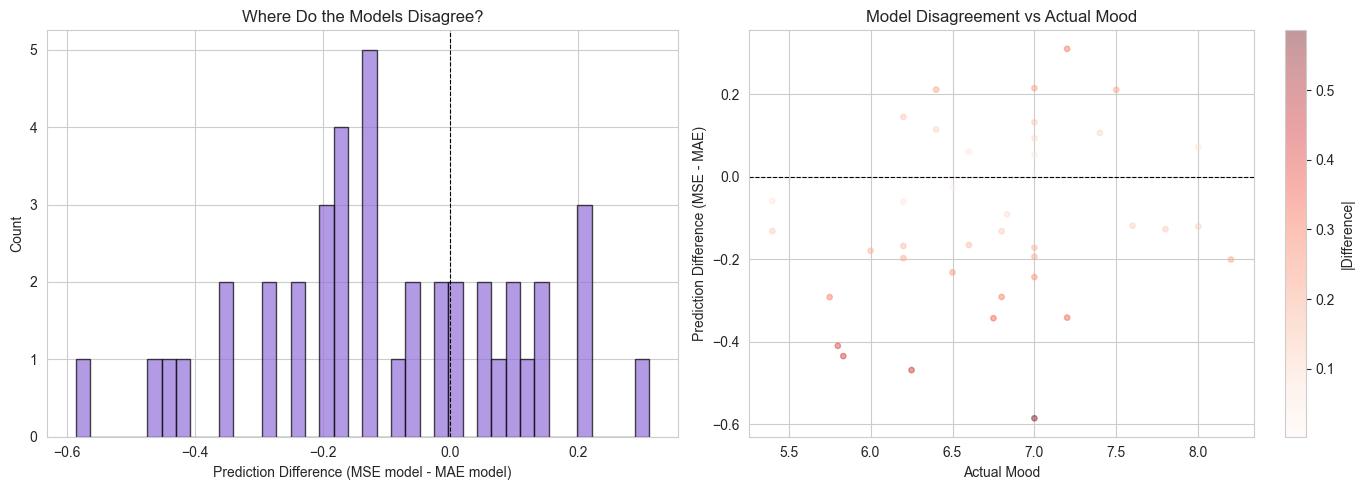

Mean absolute prediction difference: 0.1836
Max absolute prediction difference:  0.5859
Correlation between predictions: 0.7508


In [9]:
# Prediction difference: where do MSE and MAE models disagree most?
pred_diff = y_pred_mse - y_pred_mae

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribution of prediction differences
axes[0].hist(pred_diff, bins=40, color='mediumpurple', alpha=0.7, edgecolor='black')
axes[0].axvline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('Prediction Difference (MSE model - MAE model)')
axes[0].set_ylabel('Count')
axes[0].set_title('Where Do the Models Disagree?')

# Plot 2: Prediction difference vs actual mood
scatter = axes[1].scatter(y_test, pred_diff, alpha=0.4, s=15, c=np.abs(pred_diff), cmap='Reds')
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Actual Mood')
axes[1].set_ylabel('Prediction Difference (MSE - MAE)')
axes[1].set_title('Model Disagreement vs Actual Mood')
plt.colorbar(scatter, ax=axes[1], label='|Difference|')

plt.tight_layout()
plt.show()

print(f"Mean absolute prediction difference: {np.abs(pred_diff).mean():.4f}")
print(f"Max absolute prediction difference:  {np.abs(pred_diff).max():.4f}")
print(f"Correlation between predictions: {np.corrcoef(y_pred_mse, y_pred_mae)[0,1]:.4f}")

## Section 3: Analysis and Implications

### 3.1 How do the models differ in their error distributions?

The MSE-optimized and MAE-optimized models produce different error profiles:

- **MSE-optimized model:** Minimizes squared errors, which means it approximates
  the *conditional mean* of the target. Because squaring amplifies large errors,
  this model works harder to reduce extreme prediction mistakes. The residual
  distribution tends to be more symmetric and concentrated around zero, but the
  model may sacrifice accuracy on typical samples to pull in outlier predictions.

- **MAE-optimized model:** Minimizes absolute errors, which means it approximates
  the *conditional median* of the target. Since all errors are treated linearly
  (no squaring), the model is more robust to outliers in the training data. The
  residual distribution may be tighter around the median but can have heavier
  tails, since the model does not specifically penalize large errors.

### 3.2 Outlier sensitivity

MSE penalizes a prediction error of 2.0 four times more than an error of 1.0
(penalty: 4.0 vs 1.0), while MAE penalizes it only twice as much (2.0 vs 1.0).
This quadratic penalty makes MSE-optimized models more sensitive to outliers,
which can be both an advantage (fewer catastrophic errors) and a disadvantage
(distortion of predictions for the majority of samples).

### 3.3 Which metric is more appropriate for mood prediction?

<!-- TODO: Fill in your interpretation based on the results above -->

**Considerations:**
- Mood data often contains natural variability and occasional extreme responses.
  If these extremes are genuine (not measurement errors), MSE may be preferable
  because missing a severe mood drop could have clinical implications.
- If extreme values are mostly noise, MAE provides a more stable and robust model
  that reflects the typical patient experience.
- In clinical settings, missing a dangerously low mood score is more costly than
  being slightly off on an average day. This asymmetry suggests MSE (or even a
  custom asymmetric loss) may be more appropriate.

<!-- TODO: Add your final recommendation based on the empirical results -->
<!-- TODO: Discuss whether the observed differences are practically significant -->

In [10]:
# Summary table
print("=== Summary: MSE vs MAE Impact ===\n")
summary_data = {
    'Aspect': [
        'Loss function',
        'Approximates',
        'Outlier sensitivity',
        'Robustness to noise',
        'Gradient behavior',
        'Best when'
    ],
    'MSE': [
        'Sum of squared errors',
        'Conditional mean',
        'High (quadratic penalty)',
        'Lower (outliers dominate loss)',
        'Proportional to error size',
        'Large errors are costly'
    ],
    'MAE': [
        'Sum of absolute errors',
        'Conditional median',
        'Low (linear penalty)',
        'Higher (robust to outliers)',
        'Constant magnitude',
        'Typical accuracy matters more'
    ]
}
summary_df = pd.DataFrame(summary_data).set_index('Aspect')
print(summary_df.to_string())

=== Summary: MSE vs MAE Impact ===

                                                MSE                            MAE
Aspect                                                                            
Loss function                 Sum of squared errors         Sum of absolute errors
Approximates                       Conditional mean             Conditional median
Outlier sensitivity        High (quadratic penalty)           Low (linear penalty)
Robustness to noise  Lower (outliers dominate loss)    Higher (robust to outliers)
Gradient behavior        Proportional to error size             Constant magnitude
Best when                   Large errors are costly  Typical accuracy matters more
